<a href="https://colab.research.google.com/github/elijahmoon-hub/Elijah-s-repository/blob/main/ElijMoon_Unit7ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

!pip install git+https://github.com/pydata/xarray.git
!pip install bambi
!pip install preliz
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import xarray as xr
import bambi as bmb
import pymc as pm

  Cloning https://github.com/pydata/xarray.git to /tmp/pip-req-build-t8wxr8oq
  Running command git clone --filter=blob:none --quiet https://github.com/pydata/xarray.git /tmp/pip-req-build-t8wxr8oq
  Resolved https://github.com/pydata/xarray.git to commit 885e8d111996e4164bac2a3179ff9f4361d58c7b
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for xarray: filename=xarray-2026.2.1.dev23+g885e8d111-py3-none-any.whl size=1406047 sha256=1f9d77b583e9dbdea65d7578c6d20e7791d249ff40e140fe49d6dc0db8982de9
  Stored in directory: /tmp/pip-ephem-wheel-cache-pf2fq_2r/wheels/85/31/4d/1461a0a89ce43cb05e88257f443831a509560bcc4d5ebe482c
Successfully built xarray
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 3.1 MB/s eta 0:00:00


# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

When not concerned about overfitting and when fitting the data closer, it can be beneficial to include polynomials. For example, in the Rented ~ Hour model, there are only 24 hours in a day, so it was actually more effective to use a higher degree polynomial regression.

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

If the polynomial doesn't fit the data better than linear regression, we wouldn't need to use polynomial regression.

**Task3**:

What's the point of using b splines?

B splines make polynomial more flexible and reduces chance of overfitting. They divide data into intervals and apply polynomial regression on each of the pieces.

**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

A Gaussian Process is a method to determine where and how many knots should be placed in a model. This is done by setting each data point as a knot and observing their relationships with other knots, rather than trying to fit the data with a curve immediately.

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [3]:
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')
howell

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0
...,...,...,...,...
539,145.415,31.127751,17.0,1
540,162.560,52.163080,31.0,1
541,156.210,54.062497,21.0,0
542,71.120,8.051258,0.0,1


In [ ]:

model_poly_1 = bmb.Model("height ~ weight", howell)
idata_poly_1 = model_poly_1.fit()

In [ ]:


model_poly_4 = bmb.Model("height ~ poly(weight, degree=4)", howell)
idata_poly_4 = model_poly_4.fit()

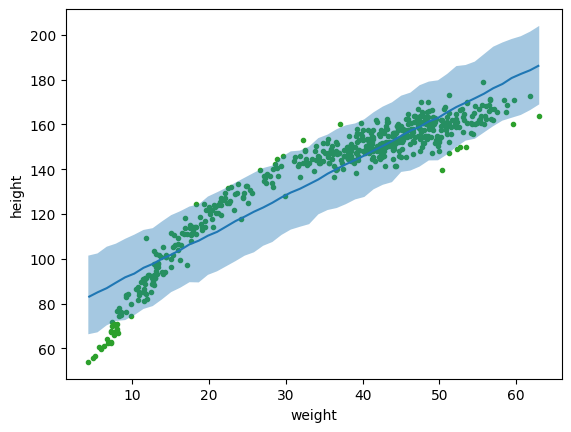

In [ ]:
bmb.interpret.plot_predictions(model_poly_1, idata_poly_1, "weight", pps=True)
plt.plot(howell.weight, howell.height, "C2.", zorder=-3)

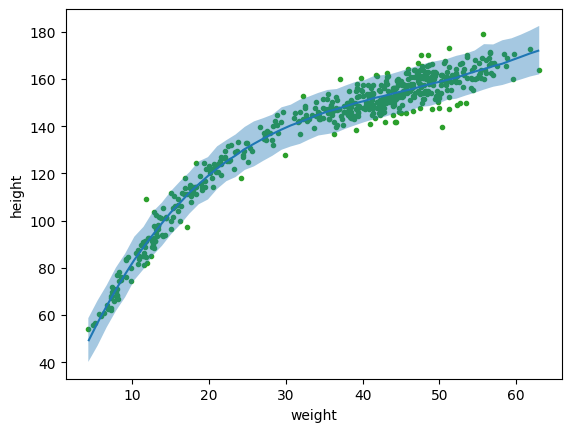

In [ ]:
bmb.interpret.plot_predictions(model_poly_4, idata_poly_4, "weight", pps=True)
plt.plot(howell.weight, howell.height, "C2.", zorder=-3)

In [4]:
weight = howell["weight"].values
height = howell["height"].values[:,None]

In [10]:
import preliz as pz

def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))

In [ ]:

prior_gp = {
    "sigma": bmb.Prior("Gamma", mu=1, sigma=0.01),
    "ell": bmb.Prior("InverseGamma", **get_ig_params(height))
}

priors = {
    "hsgp(height, m=168, c=8.0)": prior_gp,
    "alpha": bmb.Prior("HalfNormal", sigma=1)
}

# Changed family from 'negativebinomial' to 'gaussian' for continuous 'weight' data.
model_hsb = bmb.Model("weight ~ 0 + hsgp(height, m=168, c=8.0)", howell, family="gaussian", priors=priors)
idata_hsb = model_hsb.fit(nuts_kwargs={'target_accept': 0.95})


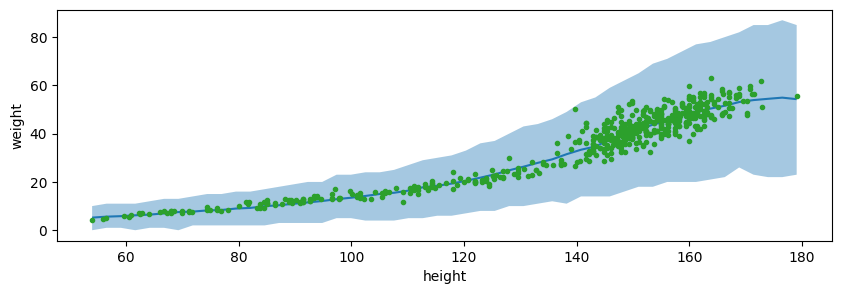

In [12]:

_, ax = bmb.interpret.plot_predictions(model_hsb, idata_hsb, ["height"],
                                       pps = True,
                                       fig_kwargs={"figsize": (10, 3)})
ax[0].plot(howell["height"].values,howell["weight"].values, "C2.")
#This gave me a lot of divergences

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

More complex covariance functions can be made by composing base covariance functions in several ways. Two of the most commonly used operations are

-The sum of two covariance functions is a covariance function

-The product of two covariance functions is a covariance function

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.

My favorite graph was a graph of samples from a Gaussian Process prior with a changepoint covariance function. It shows that before x=40, the function is smooth and slow changing, but after x=40, the function changes quickly.I enjoye this graph compared to others because I can somewhat interpret this graph, which is something I can't say for a lot of the other ones.
It's very neat and clear asthe difference between x<40 and x>40 is distinct and unmissable.